## Configuration

In [1]:
# Install dependencies
%pip install -q dagshub[jupyter]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.2/259.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.4 MB/s eta 0:00:00


In [2]:
!git config --global user.email {cheng.zhenwk@gmail.com}
!git config --global user.name {chengzwk}

In [3]:
USER_NAME = "chengzwk"

In [4]:
!dagshub login

import dagshub
TOKEN = dagshub.auth.get_token()

                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d205ddeb-ce4f-4fd0-a1bc-db7dfac216b6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e55d851eefe5102071a72dcdfb914f3fdcfd943567daa28b75e8bbc54af5dec5


⠙ Waiting for authorization

Aborted!
^C


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b3104837-2e65-45ae-97c0-95bf33cc15d1&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=460543dd26c7a6433c50bf7b9a0f925f6004301c656120b230d6678c5e9c5c99




Accessing as chengzwk

In [5]:
!git clone https://dagshub.com/Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping.git workspace
%cd workspace

Cloning into 'workspace'...
remote: Enumerating objects: 2019, done.
remote: Counting objects: 100% (2019/2019), done.
remote: Compressing objects: 100% (1991/1991), done.
remote: Total 2019 (delta 694), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (2019/2019), 6.08 MiB | 1.78 MiB/s, done.
Resolving deltas: 100% (694/694), done.
/content/workspace


In [6]:
from dagshub.streaming import install_hooks

install_hooks()

Repository "Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping" is now hooked at path "/content/workspace".
Any calls to Python file access function like open() and listdir() inside of this directory will include results 
from the repository.

## 🌳 Vegetation ratio

## Heatmap of vegetation ratio

In [7]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 69.4 MB/s eta 0:00:00


In [8]:
import os
import numpy as np
import rasterio
import rasterio.warp
import geopandas as gpd
from rasterio.transform import xy

In [9]:
# Get center coordinates of the chip
def get_chip_center(src):
    transform = src.transform
    crs = src.crs
    width, height = src.width, src.height

    # ✅ Get the actual center coordinates in the UTM projection
    center_x = width // 2
    center_y = height // 2
    utm_easting, utm_northing = rasterio.transform.xy(transform, center_y, center_x)

    # ✅ Convert UTM coordinates to Lat/Lon (EPSG:4326)
    lon, lat = rasterio.warp.transform(crs, 'EPSG:4326', [utm_easting], [utm_northing])
    lon, lat = lon[0], lat[0]  # Extract values from lists

    return lon, lat

In [10]:
# Function to compute vegetation fraction per chip
def compute_vegetation_ratio(mask_array):

    mask_array = np.transpose(mask_array, [1, 2, 0])               # move the axis for bands to the third axis
    mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0
    classes = np.arange(2, 7)                                      # class numbers: 2, 3, 4, 5, 6
    mask_array = np.argmax(mask_array, axis=2, keepdims=True) + 2  # Convert fractional mask to binary mask

    total_pixels = mask_array.size
    veg_count = np.count_nonzero(np.isin(mask_array, [3, 4]))
    veg_ratio = (veg_count / total_pixels)

    #vegetation_ratio = np.mean(mask)  # Compute average vegetation fraction

    return veg_ratio

In [11]:
# Function to compute vegetation fraction per chip
def compute_vegetation_ratio_fractional(mask_array):

    mask_array = np.transpose(mask_array, [1, 2, 0])                # move the axis for bands to the third axis
    mask_array[np.isnan(mask_array)] = 0                            # replace nan with 0

    veg_ratio = np.mean(mask_array[:, :, 1] + mask_array[:, :, 2])  # Get vegetation fraction (low-veg + tree) of each pixel, then take average

    return veg_ratio

In [12]:
IMAGE_DIR = 'MULC/VBWVA_8R'
MASK_DIR = "MULC/VBWVA_8R_masks"

# Iterate over image chips and extract vegetation data
chip_data = []  # Stores (latitude, longitude, vegetation_ratio)

image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')]

for i, filename in enumerate(image_files):
    print('{}/{} files, {}'.format(i, len(image_files), filename))

    mask_file = filename.replace('.tif', '_fractional_mask.tif')
    mask_path = os.path.join(MASK_DIR, mask_file)

    try:
        with open(mask_path, "rb") as f_mask:
            with rasterio.open(f_mask) as msk:
                lon, lat = get_chip_center(msk)
                mask_array = msk.read()  # Read all bands
                vegetation_ratio= compute_vegetation_ratio(mask_array)

        chip_data.append((lat, lon, vegetation_ratio, mask_file))

    except Exception as e:
        print(f'Error processing {mask_path}: {e}')
        continue


0/918 files, VBWVA_2016_79_3_GeoTIFF.tif
1/918 files, VBWVA_2016_178_1_GeoTIFF.tif
2/918 files, VBWVA_2016_182_2_GeoTIFF.tif
3/918 files, VBWVA_2016_205_1_GeoTIFF.tif
4/918 files, VBWVA_2016_174_3_GeoTIFF.tif
5/918 files, VBWVA_2016_106_3_GeoTIFF.tif
6/918 files, VBWVA_2016_110_3_GeoTIFF.tif
7/918 files, VBWVA_2016_113_3_GeoTIFF.tif
8/918 files, VBWVA_2016_128_1_GeoTIFF.tif
9/918 files, VBWVA_2016_39_2_GeoTIFF.tif
10/918 files, VBWVA_2016_228_3_GeoTIFF.tif
11/918 files, VBWVA_2016_293_3_GeoTIFF.tif
12/918 files, VBWVA_2016_158_2_GeoTIFF.tif
13/918 files, VBWVA_2016_281_3_GeoTIFF.tif
14/918 files, VBWVA_2016_162_3_GeoTIFF.tif
15/918 files, VBWVA_2016_228_1_GeoTIFF.tif
16/918 files, VBWVA_2016_235_3_GeoTIFF.tif
17/918 files, VBWVA_2016_153_2_GeoTIFF.tif
18/918 files, VBWVA_2016_288_3_GeoTIFF.tif
19/918 files, VBWVA_2016_43_2_GeoTIFF.tif
20/918 files, VBWVA_2016_114_2_GeoTIFF.tif
21/918 files, VBWVA_2016_78_1_GeoTIFF.tif
22/918 files, VBWVA_2016_311_3_GeoTIFF.tif
23/918 files, VBWVA_2016_

628/918 files, VBWVA_2016_81_1_GeoTIFF.tif
629/918 files, VBWVA_2016_183_1_GeoTIFF.tif
630/918 files, VBWVA_2016_68_1_GeoTIFF.tif
631/918 files, VBWVA_2016_181_2_GeoTIFF.tif
632/918 files, VBWVA_2016_274_2_GeoTIFF.tif
633/918 files, VBWVA_2016_118_1_GeoTIFF.tif
634/918 files, VBWVA_2016_301_2_GeoTIFF.tif
635/918 files, VBWVA_2016_142_1_GeoTIFF.tif
636/918 files, VBWVA_2016_70_2_GeoTIFF.tif
637/918 files, VBWVA_2016_230_2_GeoTIFF.tif
638/918 files, VBWVA_2016_80_3_GeoTIFF.tif
639/918 files, VBWVA_2016_90_2_GeoTIFF.tif
640/918 files, VBWVA_2016_298_3_GeoTIFF.tif
641/918 files, VBWVA_2016_206_3_GeoTIFF.tif
642/918 files, VBWVA_2016_19_2_GeoTIFF.tif
643/918 files, VBWVA_2016_205_2_GeoTIFF.tif
644/918 files, VBWVA_2016_237_3_GeoTIFF.tif
645/918 files, VBWVA_2016_11_1_GeoTIFF.tif
646/918 files, VBWVA_2016_41_2_GeoTIFF.tif
647/918 files, VBWVA_2016_159_3_GeoTIFF.tif
648/918 files, VBWVA_2016_160_1_GeoTIFF.tif
649/918 files, VBWVA_2016_127_1_GeoTIFF.tif
650/918 files, VBWVA_2016_20_3_GeoTIFF.t

In [13]:
import pandas as pd

lat = [t[0] for t in chip_data]
lon = [t[1] for t in chip_data]
veg_ratio = [t[2] for t in chip_data]
mask_file = [t[3] for t in chip_data]
df = pd.DataFrame({'Lat':lat,'Long':lon,'veg_ratio': veg_ratio, 'file': mask_file})

In [14]:
import plotly.graph_objects as go

fig = go.Figure(go.Densitymapbox(lat=df.Lat,
                                 lon=df.Long,
                                 z=df.veg_ratio,
                                 radius=10,
                                 colorscale=[[0.0, 'blue',],[0.3,'lime'],[0.5,'yellow'],[0.7,'orange'],[1.0, 'red']],# custome colorscale
                                 zmin=0.0,
                                 zmax=1.0
                                ))

fig.update_layout(mapbox_style="carto-positron",
                  mapbox_center_lon=-76.00,
                  mapbox_center_lat=36.85,
                  mapbox_zoom=9)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

## Simple statistics on the vegetation ratio of the dataset

In [15]:
df.head()

,Lat,Long,veg_ratio,file
0,36.837922,-76.278112,0.318054,VBWVA_2016_79_3_GeoTIFF_fractional_mask.tif
1,36.804208,-76.191462,0.603516,VBWVA_2016_178_1_GeoTIFF_fractional_mask.tif
2,36.850353,-76.192178,0.440796,VBWVA_2016_182_2_GeoTIFF_fractional_mask.tif
3,36.723736,-76.161551,0.928894,VBWVA_2016_205_1_GeoTIFF_fractional_mask.tif
4,36.758063,-76.190748,0.799744,VBWVA_2016_174_3_GeoTIFF_fractional_mask.tif


In [16]:
df['veg_ratio'].describe()  # Provides mean, std, min, max, quartiles, etc.

,veg_ratio
count,918.000000
mean,0.618589
std,0.194631
min,0.000732
25%,0.506714
50%,0.629059
75%,0.724854
max,1.000000


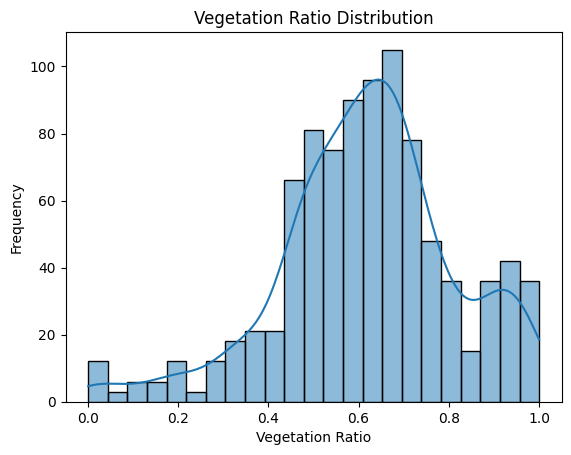

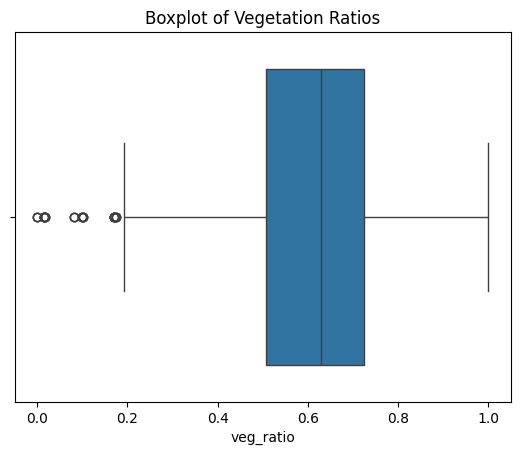

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['veg_ratio'], kde=True)
plt.title('Vegetation Ratio Distribution')
plt.xlabel('Vegetation Ratio')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=df['veg_ratio'])
plt.title('Boxplot of Vegetation Ratios')
plt.show()

In [18]:
Q1 = df['veg_ratio'].quantile(0.25)
Q3 = df['veg_ratio'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['veg_ratio'] < (Q1 - 1.5 * IQR)) | (df['veg_ratio'] > (Q3 + 1.5 * IQR))]

In [19]:
outliers

,Lat,Long,veg_ratio,file
35,36.883434,-76.336322,0.101685,VBWVA_2016_15_3_GeoTIFF_fractional_mask.tif
39,36.894969,-76.336523,0.100403,VBWVA_2016_16_2_GeoTIFF_fractional_mask.tif
78,36.837767,-76.292464,0.170593,VBWVA_2016_62_1_GeoTIFF_fractional_mask.tif
88,36.871898,-76.336121,0.000732,VBWVA_2016_14_3_GeoTIFF_fractional_mask.tif
170,36.860363,-76.335920,0.014587,VBWVA_2016_13_2_GeoTIFF_fractional_mask.tif
232,36.883594,-76.321962,0.169739,VBWVA_2016_32_3_GeoTIFF_fractional_mask.tif
245,36.883434,-76.336322,0.101685,VBWVA_2016_15_2_GeoTIFF_fractional_mask.tif
256,36.837767,-76.292464,0.170593,VBWVA_2016_62_3_GeoTIFF_fractional_mask.tif
272,36.883594,-76.321962,0.169739,VBWVA_2016_32_1_GeoTIFF_fractional_mask.tif
331,36.837767,-76.292464,0.170593,VBWVA_2016_62_2_GeoTIFF_fractional_mask.tif


In [20]:
outliers.head()

,Lat,Long,veg_ratio,file
35,36.883434,-76.336322,0.101685,VBWVA_2016_15_3_GeoTIFF_fractional_mask.tif
39,36.894969,-76.336523,0.100403,VBWVA_2016_16_2_GeoTIFF_fractional_mask.tif
78,36.837767,-76.292464,0.170593,VBWVA_2016_62_1_GeoTIFF_fractional_mask.tif
88,36.871898,-76.336121,0.000732,VBWVA_2016_14_3_GeoTIFF_fractional_mask.tif
170,36.860363,-76.335920,0.014587,VBWVA_2016_13_2_GeoTIFF_fractional_mask.tif


In [21]:
len(outliers)

30

## 🖼 Mixed pixels

## Heatmap of ratio of mixed pixels

In [29]:
# Function to compute the percentage of mixed pixels per chip
def compute_mixed_pixel_ratio(mask_array):

    mask_array = np.transpose(mask_array, [1, 2, 0])               # move the axis for bands to the third axis
    mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0

    # Define a threshold for mixed pixel
    THRESHOLD = 0.8

    # Initialize counters
    non_mixed_count = 0
    mixed_count = 0

    for i in np.arange(mask_array.shape[0]):
        for j in np.arange(mask_array.shape[1]):
            pixel = mask_array[i, j]

            if np.max(pixel) >= THRESHOLD:
                non_mixed_count += 1
            else:
                mixed_count += 1

    mixed_ratio = mixed_count / (mask_array.shape[0] * mask_array.shape[1])

    return mixed_ratio

In [30]:
IMAGE_DIR = 'MULC/VBWVA_8R'
MASK_DIR = "MULC/VBWVA_8R_masks"

# Iterate over image chips and extract vegetation data
chip_data_mixed_pixel = []  # Stores (latitude, longitude, vegetation_ratio)

image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')]

for i, filename in enumerate(image_files):
    print('{}/{} files, {}'.format(i, len(image_files), filename))

    mask_file = filename.replace('.tif', '_fractional_mask.tif')
    mask_path = os.path.join(MASK_DIR, mask_file)

    try:
        with open(mask_path, "rb") as f_mask:
            with rasterio.open(f_mask) as msk:
                lon, lat = get_chip_center(msk)
                mask_array = msk.read()  # Read all bands
                mixed_ratio= compute_mixed_pixel_ratio(mask_array)

        chip_data_mixed_pixel.append((lat, lon, mixed_ratio, mask_file))

    except Exception as e:
        print(f'Error processing {mask_path}: {e}')
        continue


0/918 files, VBWVA_2016_79_3_GeoTIFF.tif
1/918 files, VBWVA_2016_178_1_GeoTIFF.tif
2/918 files, VBWVA_2016_182_2_GeoTIFF.tif
3/918 files, VBWVA_2016_205_1_GeoTIFF.tif
4/918 files, VBWVA_2016_174_3_GeoTIFF.tif
5/918 files, VBWVA_2016_106_3_GeoTIFF.tif
6/918 files, VBWVA_2016_110_3_GeoTIFF.tif
7/918 files, VBWVA_2016_113_3_GeoTIFF.tif
8/918 files, VBWVA_2016_128_1_GeoTIFF.tif
9/918 files, VBWVA_2016_39_2_GeoTIFF.tif
10/918 files, VBWVA_2016_228_3_GeoTIFF.tif
11/918 files, VBWVA_2016_293_3_GeoTIFF.tif
12/918 files, VBWVA_2016_158_2_GeoTIFF.tif
13/918 files, VBWVA_2016_281_3_GeoTIFF.tif
14/918 files, VBWVA_2016_162_3_GeoTIFF.tif
15/918 files, VBWVA_2016_228_1_GeoTIFF.tif
16/918 files, VBWVA_2016_235_3_GeoTIFF.tif
17/918 files, VBWVA_2016_153_2_GeoTIFF.tif
18/918 files, VBWVA_2016_288_3_GeoTIFF.tif
19/918 files, VBWVA_2016_43_2_GeoTIFF.tif
20/918 files, VBWVA_2016_114_2_GeoTIFF.tif
21/918 files, VBWVA_2016_78_1_GeoTIFF.tif
22/918 files, VBWVA_2016_311_3_GeoTIFF.tif
23/918 files, VBWVA_2016_

In [31]:
import pandas as pd

lat = [t[0] for t in chip_data_mixed_pixel]
lon = [t[1] for t in chip_data_mixed_pixel]
mixed_ratio = [t[2] for t in chip_data_mixed_pixel]
mask_file = [t[3] for t in chip_data_mixed_pixel]
df_mixed_pixel = pd.DataFrame({'Lat':lat,'Long':lon,'mixed_ratio': mixed_ratio, 'file': mask_file})

In [32]:
import plotly.graph_objects as go

fig = go.Figure(go.Densitymapbox(lat=df_mixed_pixel.Lat,
                                 lon=df_mixed_pixel.Long,
                                 z=df_mixed_pixel.mixed_ratio,
                                 radius=10,
                                 colorscale=[[0.0, 'blue',],[0.3,'lime'],[0.5,'yellow'],[0.7,'orange'],[1.0, 'red']],# custome colorscale
                                 zmin=0.0,
                                 zmax=1.0
                                ))

fig.update_layout(mapbox_style="carto-positron",
                  mapbox_center_lon=-76.00,
                  mapbox_center_lat=36.85,
                  mapbox_zoom=9)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

## Simple statistics on the ratio of mixed pixels of the dataset

In [35]:
df_mixed_pixel.head()

,Lat,Long,mixed_ratio,file
0,36.837922,-76.278112,0.294434,VBWVA_2016_79_3_GeoTIFF_fractional_mask.tif
1,36.804208,-76.191462,0.398926,VBWVA_2016_178_1_GeoTIFF_fractional_mask.tif
2,36.850353,-76.192178,0.295532,VBWVA_2016_182_2_GeoTIFF_fractional_mask.tif
3,36.723736,-76.161551,0.164978,VBWVA_2016_205_1_GeoTIFF_fractional_mask.tif
4,36.758063,-76.190748,0.210083,VBWVA_2016_174_3_GeoTIFF_fractional_mask.tif


In [36]:
df_mixed_pixel['mixed_ratio'].describe()  # Provides mean, std, min, max, quartiles, etc.

,mixed_ratio
count,918.000000
mean,0.323162
std,0.128931
min,0.002747
25%,0.225342
50%,0.357697
75%,0.426819
max,0.547913


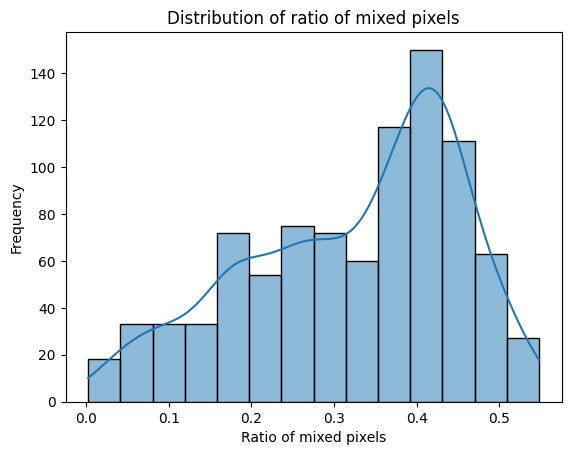

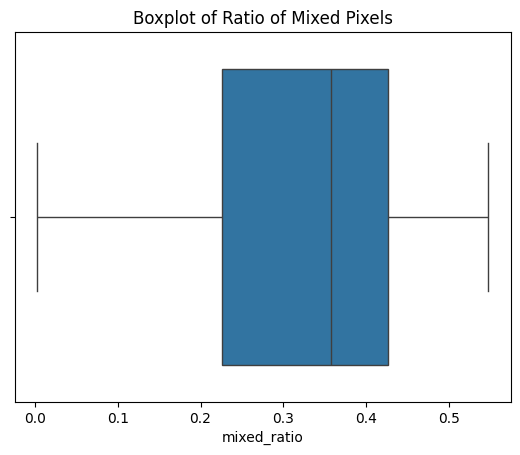

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_mixed_pixel['mixed_ratio'], kde=True)
plt.title('Distribution of ratio of mixed pixels')
plt.xlabel('Ratio of mixed pixels')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=df_mixed_pixel['mixed_ratio'])
plt.title('Boxplot of Ratio of Mixed Pixels')
plt.show()

In [43]:
Q1 = df_mixed_pixel['mixed_ratio'].quantile(0.25)
Q3 = df_mixed_pixel['mixed_ratio'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_mixed_pixel[(df_mixed_pixel['mixed_ratio'] < (Q1 - 1.5 * IQR)) | (df_mixed_pixel['mixed_ratio'] > (Q3 + 1.5 * IQR))]

In [44]:
outliers.head()

,Lat,Long,mixed_ratio,file


In [45]:
len(outliers)

0

## Save notebook

In [ ]:
from dagshub.notebook import save_notebook

USER_NAME = "chengzwk"
REPO_NAME = "omdena-frankfurt-ugs-unet"

repo = f"{USER_NAME}/{REPO_NAME}"
notebook_path = "Unet_Resnet50/data-exploration.ipynb"

# Add the commit message
commit_message = "Plot heat map and statistics for ratio of mixed pixels in mask files."

save_notebook(repo=repo,
              branch = "main",
              path=notebook_path,
              commit_message=commit_message,
              versioning="git")